# **Survival Analysis with `lifelines` — Guided Notebook (In-class Activity)**

**Main goals**
- Understand the data format: durations **T** and event indicator **E**
- Estimate and interpret **Kaplan–Meier** survival curves
- Compare groups with **log-rank test**
- Interpret Cox Proportional Hazards (CoxPH) regression
- Short review of parametric AFT mdoels

In [ ]:
%%capture
pip install lifelines

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines.statistics import logrank_test
from lifelines.datasets import load_dd, load_rossi
from lifelines import KaplanMeierFitter, CoxPHFitter

# plotting defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Political Regimes (time in office)


<p align = "justify"> In this example, we will investigate the lifespans of political leaders around the world. A political leader, in this case, is defined by a single individual’s time in office who controls the ruling regime. This political leader could be an elected president, an unelected dictator, a monarch, or another type of leader. The birth event is the start of the individual’s tenure, and the death event is the voluntary retirement of the individual. Censoring can occur if they are
<ol type = "a">
 <li>still in offices at the time of dataset compilation (2008)</li>
 <li>die while in power (this includes assassinations)</li>
 </ol>

*Example:* the Bush regime began in 2000 and officially ended in 2008 upon his retirement; thus, its lifespan was eight years, and a “death” event was observed. On the other hand, the JFK regime lasted 2 years, from 1961 to 1963, and the regime’s official death event was not observed – JFK died before his official retirement.<br><br>

Let’s bring in our dataset.</p>


**References:**
Cheibub, José Antonio, Jennifer Gandhi, and James Raymond Vreeland. 2010. “Democracy and Dictatorship Revisited.” Public Choice, vol. 143, no. 2-1, pp. 67-101.

## 1) Dataset Description

In [ ]:
# Load the dataset (leader tenure / regime duration)
data = load_dd()

# Quick look at the available columns
list(data.columns)

['ctryname',
 'cowcode2',
 'politycode',
 'un_region_name',
 'un_continent_name',
 'ehead',
 'leaderspellreg',
 'democracy',
 'regime',
 'start_year',
 'duration',
 'observed']

### Data dictionary (key columns)

- `duration`: duration (weeks) → this is **T**
- `observed`: event indicator (1 = event happened, 0 = censored) → this is **E/δ**
- `ctryname`: the name of the country
- `cowcode2`: numeric country code from the Correlates of War (COW) project
- `politycode`: regime score from the Polity dataset → numerical indicator of the political regime type (typically reflecting level of democracy vs. autocracy)
- `un_region_name`: geographic region
- `un_continent_name`: continent
- `ehead`: name of the individual leader
- `leaderspellreg`: identifier for a specific period of rule
- `democracy`: indicator of democratic status
- `regime`: political regime type
- `start_year`: year the leader took office

In [ ]:
# Show a compact view of the most important columns
cols = ["ctryname", "start_year", "duration", "observed", "democracy", "regime", "ehead"]
data[cols].head()

,ctryname,start_year,duration,observed,democracy,regime,ehead
0,Afghanistan,1946,7,1,Non-democracy,Monarchy,Mohammad Zahir Shah
1,Afghanistan,1953,10,1,Non-democracy,Civilian Dict,Sardar Mohammad Daoud
2,Afghanistan,1963,10,1,Non-democracy,Monarchy,Mohammad Zahir Shah
3,Afghanistan,1973,5,0,Non-democracy,Civilian Dict,Sardar Mohammad Daoud
4,Afghanistan,1978,1,0,Non-democracy,Civilian Dict,Nur Mohammad Taraki


In [ ]:
# Basic summary: sample size, censoring rate, and group sizes
N = len(data)
n_events = int(data["observed"].sum())
n_censored = N - n_events

print(f"N = {N}")
print(f"Events (left office alive) = {n_events}")
print(f"Censored (did NOT observe event) = {n_censored}")
print(f"Censoring rate = {n_censored / N:.1%}")

print("\nGroup sizes (democracy):")
display(data["democracy"].value_counts())

print("\nEvent rate by group (mean of observed):")
display(data.groupby("democracy")["observed"].mean().rename("event_rate"))

print("\nDuration summary (years):")
display(data["duration"].describe())

N = 1808
Events (left office alive) = 1468
Censored (did NOT observe event) = 340
Censoring rate = 18.8%

Group sizes (democracy):


,count
democracy,
Democracy,1187
Non-democracy,621



Event rate by group (mean of observed):


,event_rate
democracy,
Democracy,0.865206
Non-democracy,0.710145



Duration summary (years):


,duration
count,1808.000000
mean,5.043695
std,6.208406
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,47.000000


### 🧠 Your turn to interpret the dataset information. Give an answer to the following questions:

1) In this dataset, what is the **event**? What does `observed = 1` mean in words?  
2) What does it mean when `observed = 0`? What are plausible reasons in this dataset?  
3) Is it always valid to treat “death in office” as **censoring**? Under what assumption would it be acceptable?



---



### 2) Survival curve for all regimes (Kaplan-Meier Estimator)



To estimate the survival function, we first will use the [Kaplan-Meier Estimate](https://en.wikipedia.org/wiki/Kaplan%E2%80%93Meier_estimator), defined as:

$$\hat{S}(t) = \prod_{t_i < t} \frac{n_i - d_i}{n_i}$$

where $d_i$ are the number of death events (single individual’s time in office) at time $t$ and $n_i$ is the number of subjects at risk of death just before time $t$. `S(t)` here means: **probability a regime/leader is still in office after `t` years**.<br><br>

From the *lifelines* library, we’ll need the `KaplanMeierFitter` for this exercise:

In [ ]:
kmf = KaplanMeierFitter()

For this estimation, we need the duration each leader was/has been in office, and whether or not they were observed to have left office (leaders who died in office or were in office in 2008, the latest date this data was record at, do not have observed death events)

We next use the KaplanMeierFitter method fit() to fit the model to the data.

Below we fit our data with the KaplanMeierFitter:

In [ ]:
T = data["duration"]
E = data["observed"]

kmf.fit(T, event_observed=E, label="All regimes")

<lifelines.KaplanMeierFitter:"All regimes", fitted with 1808 total observations, 340 right-censored observations>

After calling the `fit()` method, the `KaplanMeierFitter` has a property called `survival_function`. The property is a Pandas DataFrame, so we can call `plot()` on it:

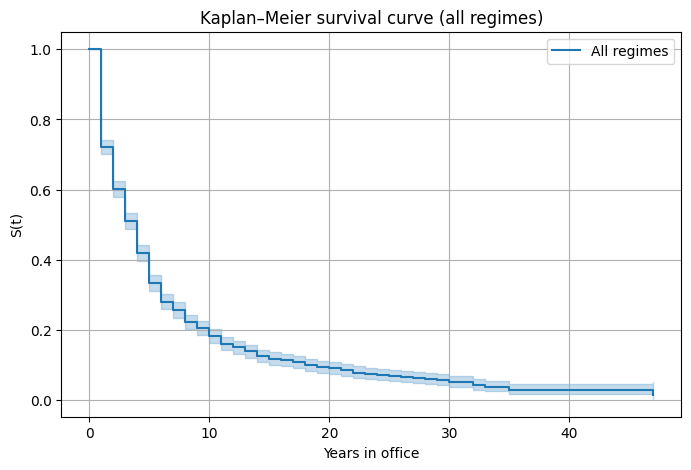

In [ ]:
ax = kmf.plot_survival_function()
ax.set_title("Kaplan–Meier survival curve (all regimes)")
ax.set_xlabel("Years in office")
ax.set_ylabel("S(t)")
plt.show()

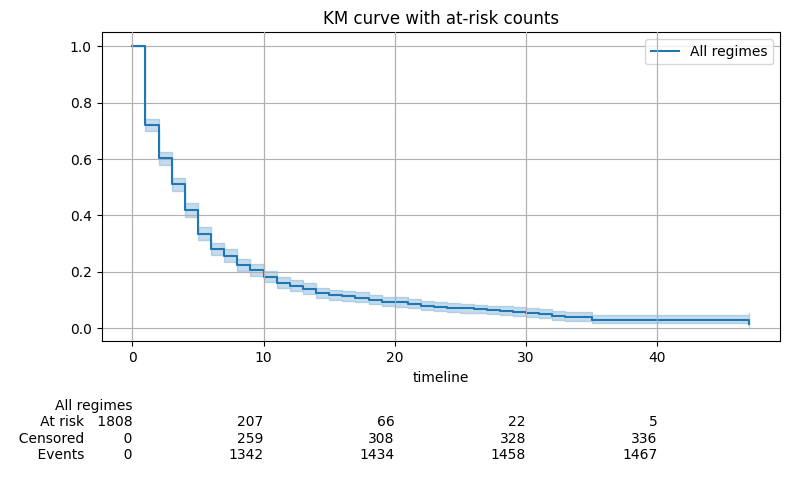

In [ ]:
# Add an at-risk table (best practice for KM plots)
ax = kmf.plot_survival_function(at_risk_counts=True)
ax.set_title("KM curve with at-risk counts")
plt.tight_layout()
plt.show()

In [ ]:
print("Median survival time (years):", kmf.median_survival_time_)

Median survival time (years): 4.0


### 🧠 Your turn to interpret these results. Give an answer to the following questions:

1) Interpret **S(t) = 0.6 at t = 5** in plain English.  
2) Why do confidence intervals typically get wider in the tail?  
3) What does the **median survival time** mean in this specific context?



---



### 3) Kaplan-Meier Estimator by group: democracy vs non-*democracy*
Let’s stratify by the `democracy` label and compare curves.

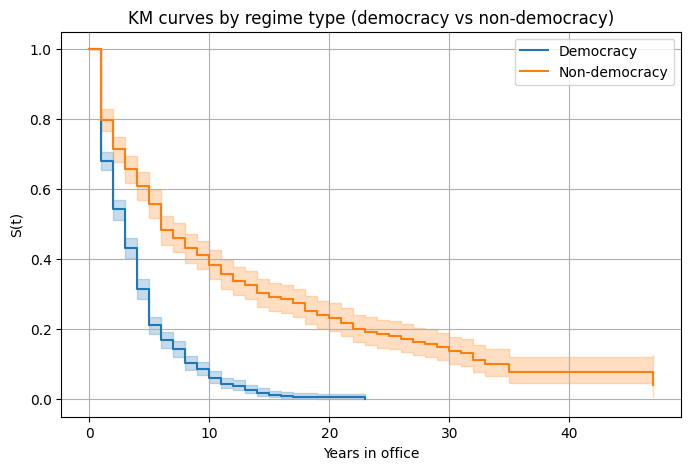

In [ ]:
dem = (data["democracy"] == "Democracy")

ax = plt.subplot(111)

kmf.fit(T[dem], event_observed=E[dem], label="Democracy")
kmf.plot_survival_function(ax=ax)

kmf.fit(T[~dem], event_observed=E[~dem], label="Non-democracy")
kmf.plot_survival_function(ax=ax)

ax.set_title("KM curves by regime type (democracy vs non-democracy)")
ax.set_xlabel("Years in office")
ax.set_ylabel("S(t)")
plt.show()

In [ ]:
# Median survival times per group
km_dem = KaplanMeierFitter().fit(T[dem], E[dem], label="Democracy")
km_nondem = KaplanMeierFitter().fit(T[~dem], E[~dem], label="Non-democracy")

print("Median (Democracy):   ", km_dem.median_survival_time_)
print("Median (Non-democracy):", km_nondem.median_survival_time_)

Median (Democracy):    3.0
Median (Non-democracy): 6.0


In [ ]:
# Evaluate survival probabilities on a fixed timeline
timeline = np.linspace(0, 50, 51)

km_dem = KaplanMeierFitter().fit(T[dem], E[dem], timeline=timeline, label="Democracy")
km_nondem = KaplanMeierFitter().fit(T[~dem], E[~dem], timeline=timeline, label="Non-democracy")

surv_at = pd.DataFrame({
    "t": timeline,
    "S_dem": km_dem.survival_function_["Democracy"].values,
    "S_nondem": km_nondem.survival_function_["Non-democracy"].values,
})
surv_at.head(12)

,t,S_dem,S_nondem
0,0.0,1.000000,1.000000
1,1.0,0.681550,0.798712
2,2.0,0.542422,0.715339
3,3.0,0.432447,0.657841
4,4.0,0.314955,0.610095
5,5.0,0.210666,0.558329
6,6.0,0.168983,0.483501
7,7.0,0.142617,0.461704
8,8.0,0.103143,0.431195
9,9.0,0.085710,0.412357


### 🧠 Your turn to interpret these results. Give an answer to the following questions:

1) Which group has higher survival **early** vs **late**? Describe what you see.  
2) Pick a horizon (e.g., 10 years). Approximately what are the two survival probabilities at that time?  
3) Are the curves “roughly parallel” or do they separate differently in the tail?  
4) Give **two plausible non-technical explanations** for the difference (think domain constraints).



---



### 4) Log-rank test: is the difference statistically significant?
The log-rank test compares two survival curves under the null hypothesis that they are the same.

 🧠 Your turn before running it: do you expect the p-value to be **small** or **large**? Why?


In [ ]:
results = logrank_test(
    T[dem], T[~dem],
    event_observed_A=E[dem],
    event_observed_B=E[~dem],
    alpha=0.95
)

results.print_summary()

### 🧠 Your turn to interpret the test
1) State the null hypothesis \(H_0\) in one sentence.  
2) If the p-value is tiny, does that automatically mean the effect is “large” or “important”?  
3) What else would you report besides the p-value?



---



---



# Rossi recidivism (time in office)


We will use the **Rossi recidivism dataset** (`load_rossi()`), commonly used as a survival example. The data pertain to 432 convicts who were released from Maryland state prisons in the 1970s and who were followed up for one year after release. Half the released convicts were assigned at random to an experimental treatment in which they were given financial aid; half did not receive aid.

**Interpretation:**
- Each row is a person in a study.
- `week` is the time duration (weeks) until either:
    <ol type = "a">
    <li>the person is rearrested (event)</li>
    <li>the study ends / the person is lost (censored)</li>
    </ol>
- `arrest` is the event indicator (1 = rearrest occurred, 0 = censored).

The other columns are covariates we will regress against the hazard of rearrest.


Let’s bring in our dataset.</p>

**References**: Rossi, P.H., R.A. Berk, and K.J. Lenihan (1980). Money, Work, and Crime: Some Experimental Results. New York: Academic Press. John Fox, Marilia Sa Carvalho (2012). The RcmdrPlugin.survival Package: Extending the R Commander Interface to Survival Analysis. Journal of Statistical Software, 49(7), 1-32.

## 1) Dataset Description

### Data dictionary (key columns)

- `week`: duration (weeks) → this is **T**
- `arrest`: event indicator (1 = event happened, 0 = censored) → this is **E/δ**
- `fin`: financial aid (binary)
- `age`: age at start (years)
- `race`: race indicator (binary in this dataset)
- `wexp`: work experience (binary)
- `mar`: married (binary)
- `paro`: parole (binary)
- `prio`: number of prior convictions/arrests (count)

In [ ]:
rossi = load_rossi()
rossi.head()

,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [ ]:
# Basic dataset summary: size, events, censoring rate, and a quick covariate overview.
N = len(rossi)
n_events = int(rossi["arrest"].sum())
n_censored = N - n_events

print(f"N = {N}")
print(f"Events (rearrest) = {n_events}")
print(f"Censored = {n_censored}")
print(f"Censoring rate = {n_censored / N:.1%}")

print("\nDuration (week) summary:")
display(rossi["week"].describe())

print("\nCovariate quick summary:")
display(rossi.drop(columns=["week","arrest"]).describe(include="all").T)

N = 432
Events (rearrest) = 114
Censored = 318
Censoring rate = 73.6%

Duration (week) summary:


,week
count,432.000000
mean,45.854167
std,12.662293
min,1.000000
25%,50.000000
50%,52.000000
75%,52.000000
max,52.000000



Covariate quick summary:


,count,mean,std,min,25%,50%,75%,max
fin,432.0,0.500000,0.500580,0.0,0.0,0.5,1.0,1.0
age,432.0,24.597222,6.113375,17.0,20.0,23.0,27.0,44.0
race,432.0,0.877315,0.328456,0.0,1.0,1.0,1.0,1.0
wexp,432.0,0.571759,0.495398,0.0,0.0,1.0,1.0,1.0
mar,432.0,0.122685,0.328456,0.0,0.0,0.0,0.0,1.0
paro,432.0,0.618056,0.486426,0.0,0.0,1.0,1.0,1.0
prio,432.0,2.983796,2.896068,0.0,1.0,2.0,4.0,18.0


### 🧠 Your turn to understand the dataset

1) What is the **event** in this dataset?  
2) What does **censoring** mean here, in plain English?  
3) Pick two covariates (e.g., `prio`, `fin`, `age`) and hypothesize: do you expect them to **increase** or **decrease** rearrest risk? Why?



---



## 2) Cox Proportional Hazards model (CoxPH)


<p align = "justify"> The idea behind Cox’s proportional hazard (CoxPH) model is that the log-hazard of an individual is a linear function of their covariates and a population-level baseline hazard that changes over time. Mathematically:



 $$\underbrace{h(t|x)}_{\text{hazard}} = \overbrace{b_0(t)}^{\text{baseline hazard}} \underbrace{\exp \left( \overbrace{\sum_{i=1}^{n} b_i(x_i - \overline{x_i})}^{\text{log-partial hazard}} \right)}_{\text{partial hazard}}$$





*Note* a few behaviors about this model: the only time component is in the baseline hazard. In the above equation, the partial hazard is a time-invariant scalar factor that only increases or decreases the baseline hazard. Thus, changes in covariates will only inflate or deflate the baseline hazard.</p>

The implementation of the Cox model in *lifelines* is under `CoxPHFitter`. We fit the model to the dataset using `fit()`. It has a `print_summary()` function that prints a tabular view of coefficients and related stats.

In [ ]:
cph = CoxPHFitter()
cph.fit(rossi, duration_col="week", event_col="arrest")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2026-02-23 10:17:58 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.75           -0.00                0.47                1.00
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.37      0.31           -0.29            0.92                0.75                2.50
wexp      -0.15      0.86      0.21           -0.57            0.27                0.57                1.30
mar       -0.43      0.65      0.38           -1.18            0.31                0.31                1.37
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.10      0.03            0.04            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.98   0.05      4.40
age          0.00 -2.61   0.01      6.79
race         0.00  1.02   0.31      1.70
wexp         0.00 -0.71   0.48      1.06
mar          0.00 -1.14   0.26      1.97
paro         0.00 -0.43   0.66      0.59
prio         0.00  3.19 <0.005      9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37

### 🧠 Your turn to interpret CoxPH output

From the summary table:

1) Which covariates are statistically significant at p < 0.05?  
2) Pick **two** covariates and interpret their **hazard ratio** (exp(coef)) in words.  
3) Which covariate seems to have the strongest association with rearrest risk?  
4) Is the concordance (C-index) “good”? What does it measure?

### Accessing fitted quantities

`lifelines` exposes:
- `cph.params_` → coefficients β
- `cph.hazard_ratios_` → exp(β)
- `cph.baseline_hazard_` and `cph.baseline_survival_` → estimated baseline functions

In [ ]:
display(cph.params_.rename("coef"))
display(cph.hazard_ratios_.rename("hazard_ratio").sort_values(ascending=False).head(10))

print("\nBaseline hazard head:")
display(cph.baseline_hazard_.head())

print("\nBaseline survival head:")
display(cph.baseline_survival_.head())


,coef
covariate,
fin,-0.379422
age,-0.057438
race,0.313900
wexp,-0.149796
mar,-0.433704
paro,-0.084871
prio,0.091497


,hazard_ratio
covariate,
race,1.368753
prio,1.095814
age,0.944181
paro,0.918631
wexp,0.860884
fin,0.684257
mar,0.648104



Baseline hazard head:


,baseline hazard
1.0,0.001958
2.0,0.001964
3.0,0.001965
4.0,0.001969
5.0,0.001975



Baseline survival head:


,baseline survival
1.0,0.998044
2.0,0.996086
3.0,0.994130
4.0,0.992174
5.0,0.990216




---



## 3) Pediction: risk scores and survival curves for individuals

CoxPH can produce:
- a **relative risk score** (partial hazard) via `predict_partial_hazard`
- a **survival curve** for a specific individual via `predict_survival_function`

We will compare “low-risk” vs “high-risk” profiles by selecting rows with low/high predicted risk.

Low-risk example:


,week,arrest,fin,age,race,wexp,mar,paro,prio
21,52,0,1,44,1,1,1,1,0


High-risk example:


,week,arrest,fin,age,race,wexp,mar,paro,prio
316,11,1,0,19,1,0,0,0,18


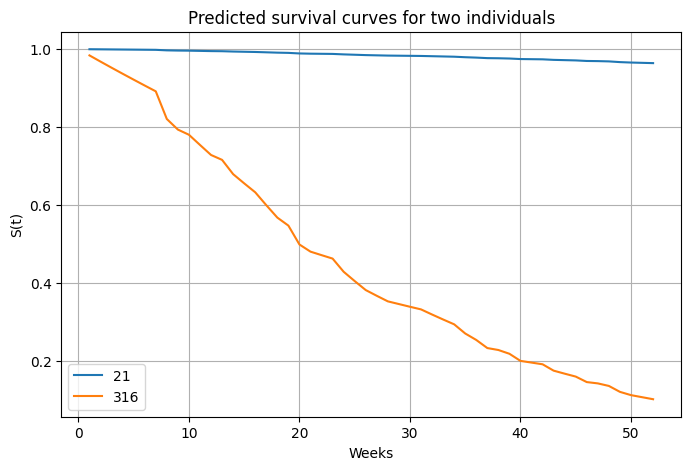

In [ ]:
# Compute risk scores for all individuals
risk = cph.predict_partial_hazard(rossi).rename("partial_hazard")
rossi_with_risk = rossi.assign(partial_hazard=risk.values)

# Pick an individual with low risk and one with high risk (by quantiles)
low = rossi_with_risk.nsmallest(1, "partial_hazard").drop(columns=["partial_hazard"])
high = rossi_with_risk.nlargest(1, "partial_hazard").drop(columns=["partial_hazard"])

print("Low-risk example:")
display(low)
print("High-risk example:")
display(high)

# Plot predicted survival functions
sf_low = cph.predict_survival_function(low)
sf_high = cph.predict_survival_function(high)

ax = sf_low.plot(label="Predicted survival (low risk)")
sf_high.plot(ax=ax, label="Predicted survival (high risk)")
ax.set_title("Predicted survival curves for two individuals")
ax.set_xlabel("Weeks")
ax.set_ylabel("S(t)")
plt.show()

### 🧠 Your turn to interpret predictions

1) Which curve should be lower: high-risk or low-risk? Why?  
2) Compare the two example rows: which covariates drive the difference?  
3) In an application, what is more useful: a **risk ranking** or an **absolute survival probability**? When?


